# Week-1 Assignment

# **Gotta catch 'em all !**

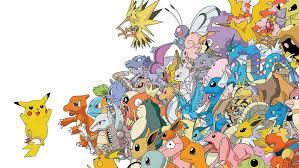

**Welcome to your first graded assignment! Hope that you are excited to implement and test everything you have learnt up until now. The dataset which you'll use includes information about Pokemons.**

**We have got an interesting set of questions for you to get a basic understanding of pandas and data visualization libraries. GOOD LUCK!**


***Let's get started with importing numpy, pandas, seaborn and matplotlib!***

Note - matplotlib should be imported with the command :

 `import matplotlib.pyplot as plt`

### 1) Start by importing all important libraries
For eg, "import numpy as np"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2) Read the csv file and assign it to a variable .

In [2]:
# your code here
df = pd.read_csv("W1_Pokemon.csv")

### 3) Display shape of dataframe
Expected Output - (800, 13)

In [3]:
# your code here
print(df.shape)

(800, 13)


### 4) Print all columns of dataframe
Return an array containing names of all the columns.

In [4]:
# your code here
print(df.columns)

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='str')


### 5) Remove the column '#' and update the dataframe.

In [5]:
# your code here
df.drop(columns=["#"], inplace=True)
df.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


### 6) Set the 'Name' column as the index of dataframe

In [6]:
# your code here
df.set_index("Name", inplace=True)
print(df.head())

                      Type 1  Type 2  Total  HP  Attack  Defense  Sp. Atk  \
Name                                                                        
Bulbasaur              Grass  Poison    318  45      49       49       65   
Ivysaur                Grass  Poison    405  60      62       63       80   
Venusaur               Grass  Poison    525  80      82       83      100   
VenusaurMega Venusaur  Grass  Poison    625  80     100      123      122   
Charmander              Fire     NaN    309  39      52       43       60   

                       Sp. Def  Speed  Generation  Legendary  
Name                                                          
Bulbasaur                   65     45           1      False  
Ivysaur                     80     60           1      False  
Venusaur                   100     80           1      False  
VenusaurMega Venusaur      120     80           1      False  
Charmander                  50     65           1      False  


###  7) Print a list of all the unique Type-1 powers

In [7]:
# your code here
np.array(df["Type 1"].unique())

array(['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Poison', 'Electric',
       'Ground', 'Fairy', 'Fighting', 'Psychic', 'Rock', 'Ghost', 'Ice',
       'Dragon', 'Dark', 'Steel', 'Flying'], dtype=object)

### 8) Create a column which contains the Type 1 and Type 2 abilities of pokemons, seperated with a '+'' sign. Also, display the no. of pokemons that have type-1 power as 'Psychic' and type 2 power as 'Flying' using this new column.

In [8]:
# your code here
df["new_col"] = df["Type 1"] + "+" + df["Type 2"]
len(df[df["new_col"] == "Psychic+Flying"])

6

## GRADED Questions (To be answered in the quiz)
### Try to retrieve some information from the data and answer the questions below . BEST OF LUCK !!

### 1. How many pokemons have 'Mega' in their name?

In [9]:
# your code here
megaPokemoncnt = 0
for i in df.index:
    if "Mega" in i:
        megaPokemoncnt += 1

print(megaPokemoncnt)

49


### 2. What is the standard deviation of Sp. Def. in the dataset ?

In [10]:
print(df["Sp. Atk"].std())
# print(np.array(df["Sp. Atk"]).std())

32.7222941688016


### 3. What percentage (upto 3 decimal places) of pokemons are legendary ?

In [11]:
total_pokemon = len(df)
legendary_pokemon = df[df["Legendary"] == True]["Legendary"].count()

print(np.round((legendary_pokemon / total_pokemon) * 100, 3))

8.125


### 4. Name the pokemon(s) with Maximum Defense.

In [12]:
# your code here
max_defence = df["Defense"].max()
print(df[df["Defense"] == max_defence].index)

Index(['SteelixMega Steelix', 'Shuckle', 'AggronMega Aggron'], dtype='str', name='Name')


### 5. Which poison pokemon has the strongest attack ?

In [13]:
# your code here
poison_pokemon_maxAttack = df[(df["Type 1"] == "Poison") | (df["Type 2"] == "Poison")][
    "Attack"
].max()

df[
    ((df["Type 1"] == "Poison") | (df["Type 2"] == "Poison"))
    & (df["Attack"] == poison_pokemon_maxAttack)
].index

Index(['BeedrillMega Beedrill'], dtype='str', name='Name')

### 6. Using seaborn make different types of plots, observe the trend and answer the questions given in the form.

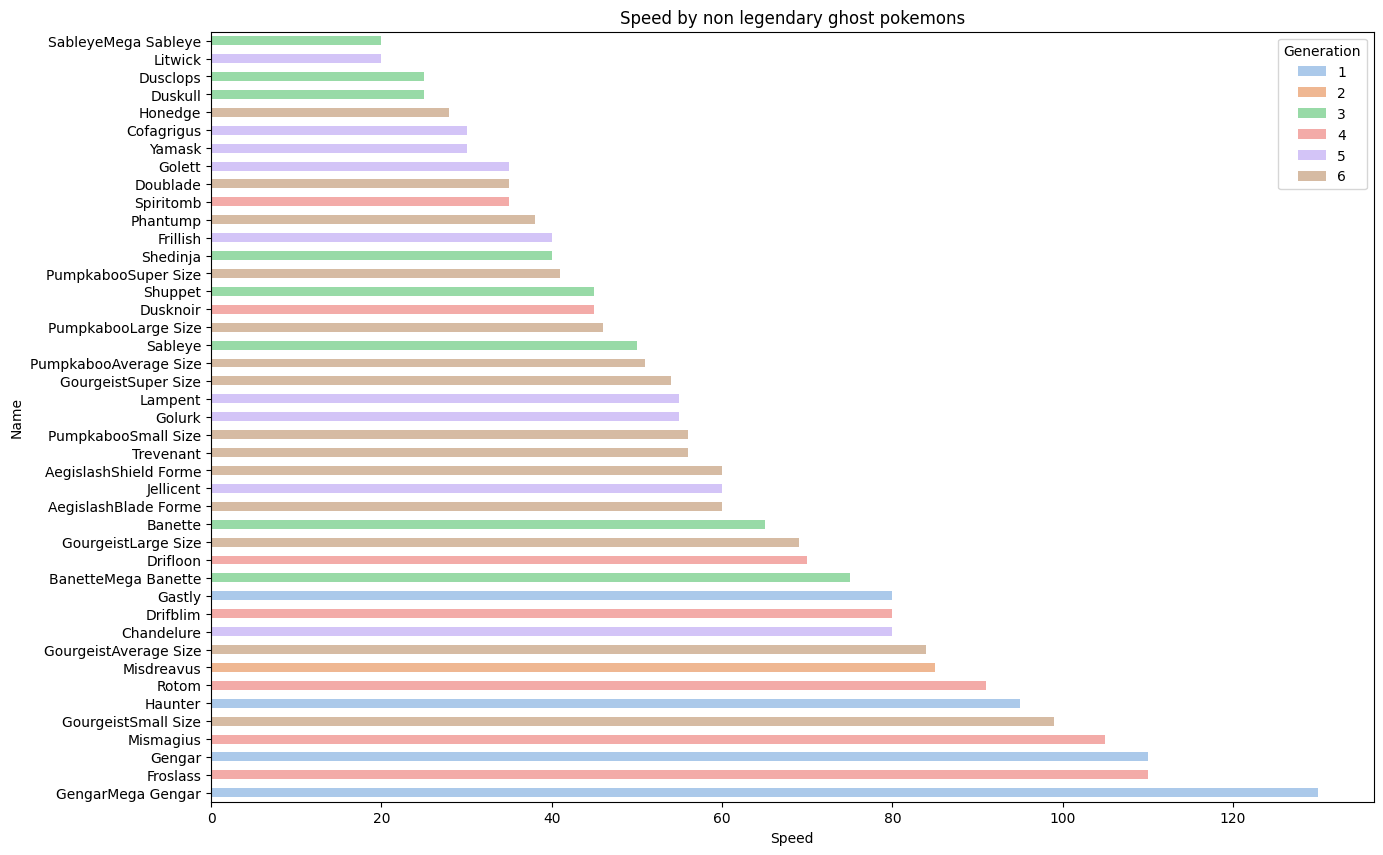

In [71]:
# your code here
ghost_condition = (df["Type 1"] == "Ghost") | (df["Type 2"] == "Ghost")
gen4_condition = df["Generation"] == 4
non_legendary_condition = df["Legendary"] == False


plt.figure(figsize=(15, 10))
plt.title("Speed by non legendary ghost pokemons")
sns.barplot(
    df[ghost_condition & non_legendary_condition].sort_values(by=["Speed"]),
    x="Speed",
    y="Name",
    width=0.5,
    palette="pastel",
    hue="Generation",
)
plt.show()

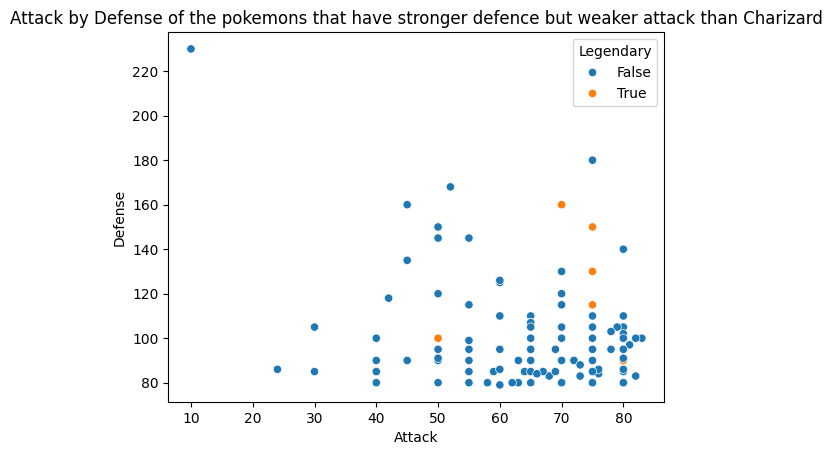

In [70]:
charizard = df.loc["Charizard"]

target_pokemon = df[
    (non_legendary_condition)
    & (df["Defense"] > charizard.Defense)
    & (df["Attack"] < charizard.Attack)
]
plt.title('Attack by Defense of the pokemons that have stronger defence but weaker attack than Charizard')
sns.scatterplot(
    df[(df["Defense"] > charizard.Defense) & (df["Attack"] < charizard.Attack)],
    x="Attack",
    y="Defense",
    hue='Legendary'
)



plt.show()

### 7. Which is the second fastest non-legendary 'Ghost' type pokemon from 4th generation ?

In [69]:
df[ghost_condition & non_legendary_condition &gen4_condition].sort_values(by=["Speed"],ascending=False).index[1]

'Mismagius'

### 8. How many non-legendary pokemons have stronger defence but weaker attack than Charizard?

In [65]:
len(target_pokemon)

116


## ***Bonus Questions***
## Here are some bonus questions that you can try further !

### These questions are UNGRADED, and are given as an extra exercise.

### Which pokemon has the highest combined value of Attack and Sp. Atk ?

In [ ]:
# your code here
df["combine_attack"] = df["Attack"] + df["Sp. Atk"]
max_combine_atk = df["combine_attack"].max()
df[df["combine_attack"] == max_combine_atk]

,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,new_col,combine_attack
Name,,,,,,,,,,,,,
RayquazaMega Rayquaza,Dragon,Flying,780,105,180,100,180,100,115,3,True,Dragon+Flying,360
DeoxysAttack Forme,Psychic,NaN,600,50,180,20,180,20,150,3,True,NaN,360


### Which type of legendary pokemons are the most common?

In [ ]:
# your code here
all_types = pd.concat(
    [df[df["Legendary"] == True]["Type 1"], df[df["Legendary"] == True]["Type 2"]]
)
all_types.value_counts().index[0]

'Psychic'

### How many generation-3, non-legendary pokemons have higher HP than the weakest generation-6, legendary pokemon?

In [ ]:
# your code here
weakest_gen6_lengendary = (
    df[(df["Legendary"] == True) & (df["Generation"] == 6)]
    .sort_values(by=["Attack"])
    .iloc[0]
    .HP
)
len(
    df[
        ((df["Generation"] == 3) & non_legendary_condition)
        & (df["HP"] > weakest_gen6_lengendary)
    ]
)

95

### Print out the third slowest pokemon(s) in the dataset.

In [ ]:
# your code here

df.sort_values(by=["Speed"]).iloc[2]

Type 1            Ground
Type 2               NaN
Total                290
HP                    45
Attack               100
Defense               45
Sp. Atk               45
Sp. Def               45
Speed                 10
Generation             3
Legendary          False
new_col              NaN
combine_attack       145
Name: Trapinch, dtype: object

### Which pokemon type has the highest average HP?

In [ ]:
# your code here
print(
    df.groupby(by=["Type 1", "Type 2"])["HP"]
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

('Ghost', 'Dragon')
